Nama : Ronny Rajagukguk

Kelas : Robotika A Pagi

Tugas : CNN



In [2]:
from google.colab import files

uploaded = files.upload()


Saving ZIp.zip to ZIp.zip


In [5]:
import zipfile

zip_path = "/content/ZIp.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [6]:
import os

os.listdir("/content/TrashType_Image_Dataset")

['metal', 'glass', 'trash', 'paper', 'cardboard', 'plastic']

In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

dataset_path = "/content/TrashType_Image_Dataset"

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.


['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


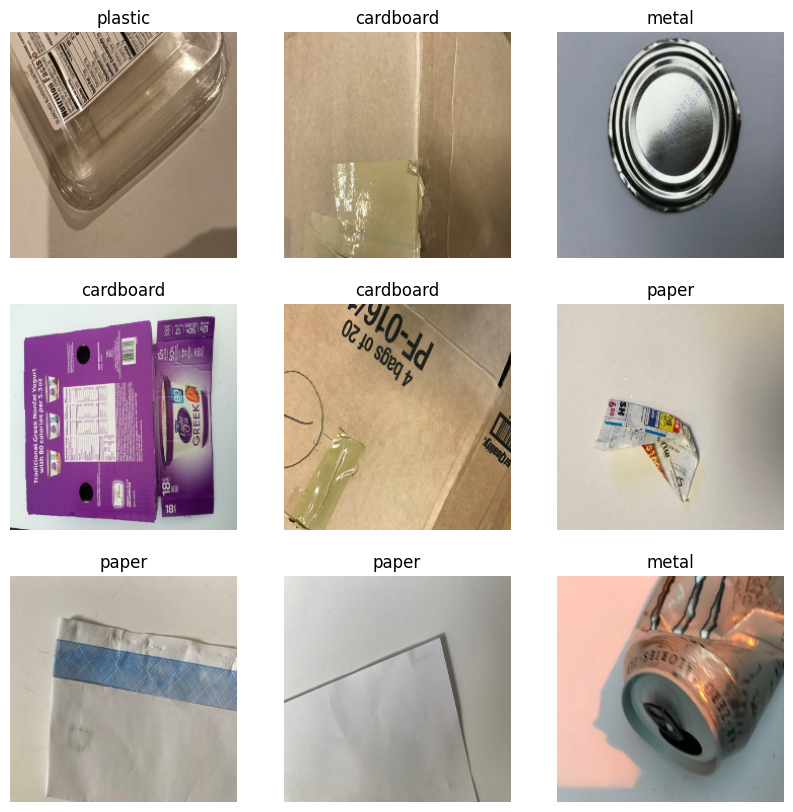

In [8]:
class_names = train_dataset.class_names
print(class_names)

plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

## Membangun Model CNN

In [9]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # Layer 1
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D((2,2)),

    # Layer 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Layer 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(len(class_names), activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## Compile Model dan Training Model

In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.9298 - loss: 0.2160 - val_accuracy: 0.6158 - val_loss: 2.0005
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.9421 - loss: 0.1644 - val_accuracy: 0.6218 - val_loss: 2.1366
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.9461 - loss: 0.1630 - val_accuracy: 0.6297 - val_loss: 2.2546
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.9505 - loss: 0.1524 - val_accuracy: 0.6257 - val_loss: 2.1279
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.9337 - loss: 0.1922 - val_accuracy: 0.5762 - val_loss: 2.2480
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.9525 - loss: 0.1327 - val_accuracy: 0.5287 - val_loss: 2.8033
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.9496 - loss: 0.1344 - val_accuracy: 0.5901 - val_loss: 2.6488
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.9446 - loss: 0.1566 - val_accuracy: 0.5644 - v

## Visualisasi Akurasi

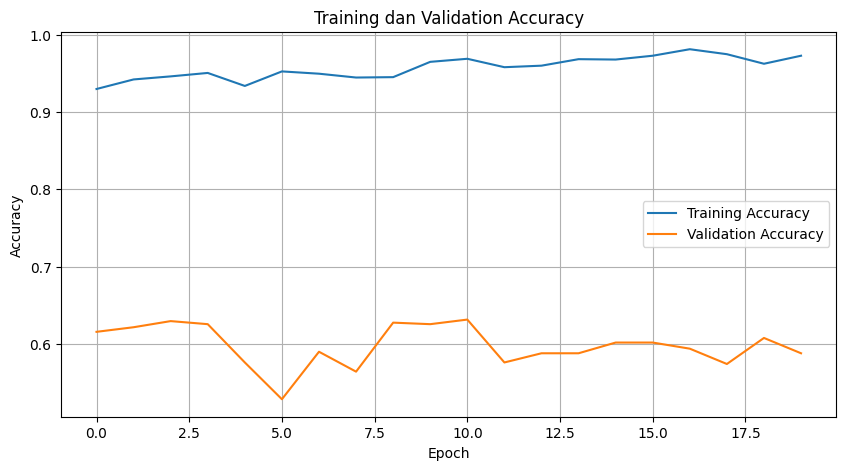

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training dan Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

## Visualisasi Loss

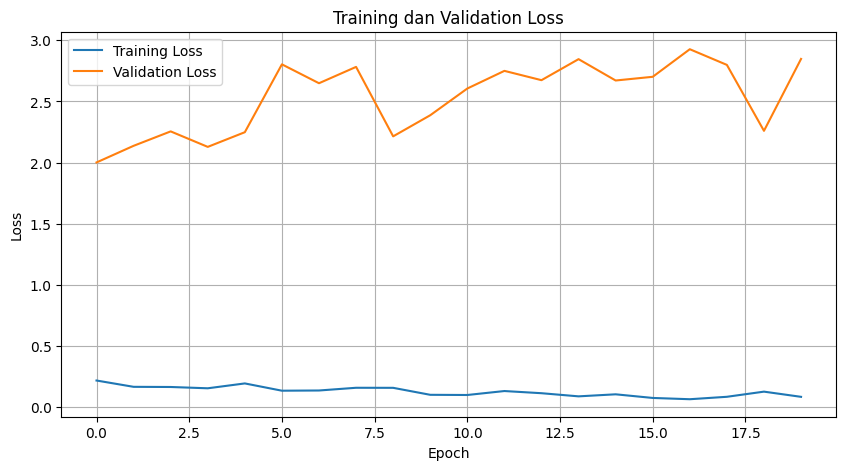

In [16]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training dan Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

## Evaluasi Model & Confusion Matrix dan Classification Report

In [17]:
loss, accuracy = model.evaluate(validation_dataset)

print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy)

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in validation_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)

print(cm)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 578ms/step - accuracy: 0.5881 - loss: 2.8476
Validation Loss : 2.847642183303833
Validation Accuracy : 0.5881187915802002
[[64  3  4  6  4  2]
 [ 6 54 17 10 15  1]
 [ 4 15 37 15  4  3]
 [ 4 14  8 93  5  0]
 [ 4 22  9  8 41  4]
 [ 2  9  4  5  1  8]]
              precision    recall  f1-score   support

   cardboard       0.76      0.77      0.77        83
       glass       0.46      0.52      0.49       103
       metal       0.47      0.47      0.47        78
       paper       0.68      0.75      0.71       124
     plastic       0.59      0.47      0.52        88
       trash       0.44      0.28      0.34        29

    accuracy                           0.59       505
   macro avg       0.57      0.54      0.55       505
weighted avg       0.59      0.59      0.58       505



## Prediksi Gambar Baru

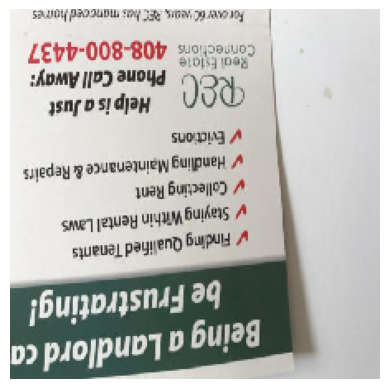

Prediksi : paper
Confidence : 100.00%


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Pilih salah satu gambar dari dataset
img_path = "/content/TrashType_Image_Dataset/paper/paper_476.jpg"

# Load gambar
img = image.load_img(img_path, target_size=(224,224))

# Tampilkan gambar
plt.imshow(img)
plt.axis("off")
plt.show()

# Preprocessing
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Prediksi
prediction = model.predict(img_array, verbose=0)

predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

print("Prediksi :", predicted_class)
print("Confidence : {:.2f}%".format(confidence))

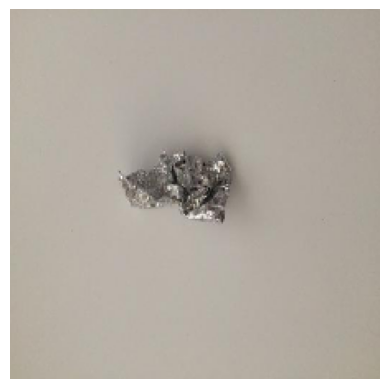

Prediksi : metal
Confidence : 98.35%


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Pilih salah satu gambar dari dataset
img_path = "/content/TrashType_Image_Dataset/metal/metal_165.jpg"

# Load gambar
img = image.load_img(img_path, target_size=(224,224))

# Tampilkan gambar
plt.imshow(img)
plt.axis("off")
plt.show()

# Preprocessing
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Prediksi
prediction = model.predict(img_array, verbose=0)

predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

print("Prediksi :", predicted_class)
print("Confidence : {:.2f}%".format(confidence))

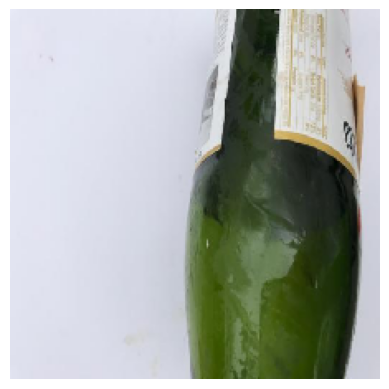

Prediksi : glass
Confidence : 100.00%


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Pilih salah satu gambar dari dataset
img_path = "/content/TrashType_Image_Dataset/glass/glass_291.jpg"

# Load gambar
img = image.load_img(img_path, target_size=(224,224))

# Tampilkan gambar
plt.imshow(img)
plt.axis("off")
plt.show()

# Preprocessing
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Prediksi
prediction = model.predict(img_array, verbose=0)

predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

print("Prediksi :", predicted_class)
print("Confidence : {:.2f}%".format(confidence))

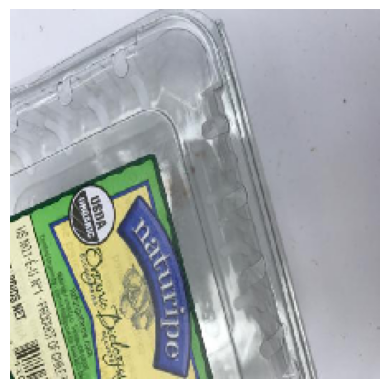

Prediksi : plastic
Confidence : 100.00%


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Pilih salah satu gambar dari dataset
img_path = "/content/TrashType_Image_Dataset/plastic/plastic_163.jpg"

# Load gambar
img = image.load_img(img_path, target_size=(224,224))

# Tampilkan gambar
plt.imshow(img)
plt.axis("off")
plt.show()

# Preprocessing
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Prediksi
prediction = model.predict(img_array, verbose=0)

predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

print("Prediksi :", predicted_class)
print("Confidence : {:.2f}%".format(confidence))

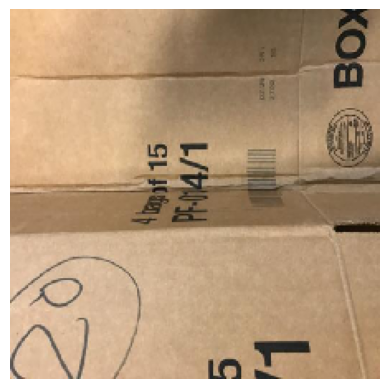

Prediksi : cardboard
Confidence : 100.00%


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Pilih salah satu gambar dari dataset
img_path = "/content/TrashType_Image_Dataset/cardboard/cardboard_329.jpg"

# Load gambar
img = image.load_img(img_path, target_size=(224,224))

# Tampilkan gambar
plt.imshow(img)
plt.axis("off")
plt.show()

# Preprocessing
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Prediksi
prediction = model.predict(img_array, verbose=0)

predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

print("Prediksi :", predicted_class)
print("Confidence : {:.2f}%".format(confidence))

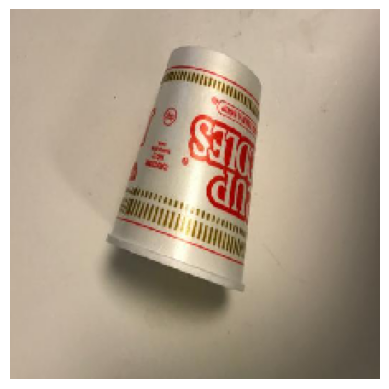

Prediksi : metal
Confidence : 83.93%


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Pilih salah satu gambar dari dataset
img_path = "/content/TrashType_Image_Dataset/trash/trash_079.jpg"

# Load gambar
img = image.load_img(img_path, target_size=(224,224))

# Tampilkan gambar
plt.imshow(img)
plt.axis("off")
plt.show()

# Preprocessing
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Prediksi
prediction = model.predict(img_array, verbose=0)

predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

print("Prediksi :", predicted_class)
print("Confidence : {:.2f}%".format(confidence))